In [290]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, MiniBatchKMeans
import umap
from collections import Counter

<h1>Show the Data:</h1>

In [291]:
# Load Data
df = pd.read_csv("All-courses.csv")

In [292]:
# Function to safely parse each skills entry into a Python list
def parse_skills(x):
    try:
        # Convert the string representation of a list into a real list,
        # then clean and lowercase each skill
        return [s.strip().lower() for s in ast.literal_eval(x)]
    except:
        # If parsing fails (bad format, NaN, etc.), return an empty list
        return []

# Apply the parsing function to the skills_list column
df["skills_list"] = df["skills_list"].apply(parse_skills)

In [293]:
# Create a long column of all skills by exploding the list column
all_skills = df.explode("skills_list")["skills_list"].dropna()

# Convert to a list of unique skills
unique_skills = all_skills.unique().tolist()

In [294]:
# Print number of unique skills found in the dataset
print("Total unique skills:", len(unique_skills))

Total unique skills: 354


<h1>TOP 45 FREQUENCY</h1>

In [295]:
# Count how many times each skill appears across all courses
skill_counts = Counter(all_skills)

In [296]:
# Extract the top 45 most frequent skills (just the skill names)
top45_freq = [s for s, _ in skill_counts.most_common(45)]

# Convert the top 45 skills and their counts into a DataFrame for plotting
top45_freq_df = pd.DataFrame(skill_counts.most_common(45), columns=["skill", "count"])

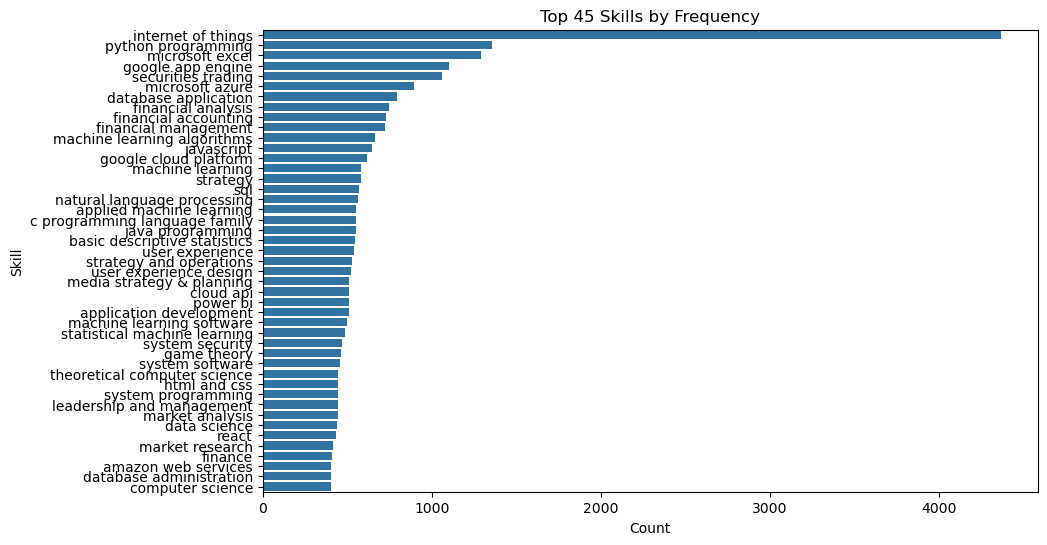

In [297]:
# Create a bar chart of the top 45 skills
plt.figure(figsize=(10,6))
sns.barplot(data=top45_freq_df, x="count", y="skill")

# Add plot title and axis labels
plt.title("Top 45 Skills by Frequency")
plt.xlabel("Count")
plt.ylabel("Skill")

# Display the plot
plt.show()

<h1>TOP 45 TF-IDF</h1>

In [298]:
# Convert each list of skills into a single string separated by " | "
df["skills_text"] = df["skills_list"].apply(lambda x: " | ".join(x))

In [299]:
# Create a TF-IDF vectorizer that splits skills using our custom separator
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(" | "), lowercase=True)

# Transform the skills_text column into a TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(df["skills_text"])

# Get the list of all skill names (features) from the TF-IDF model
feature_names = vectorizer.get_feature_names_out()

# Sum TF-IDF scores for each skill across all courses
tfidf_sums = tfidf_matrix.sum(axis=0).A1

# Create a DataFrame of skills and their total TF-IDF scores, sorted descending
tfidf_df = pd.DataFrame({
    "skill": feature_names,
    "tfidf": tfidf_sums
}).sort_values("tfidf", ascending=False)

# Extract the top 45 skills by TF-IDF value
top45_tfidf = tfidf_df.head(45)

C:\Users\habee\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


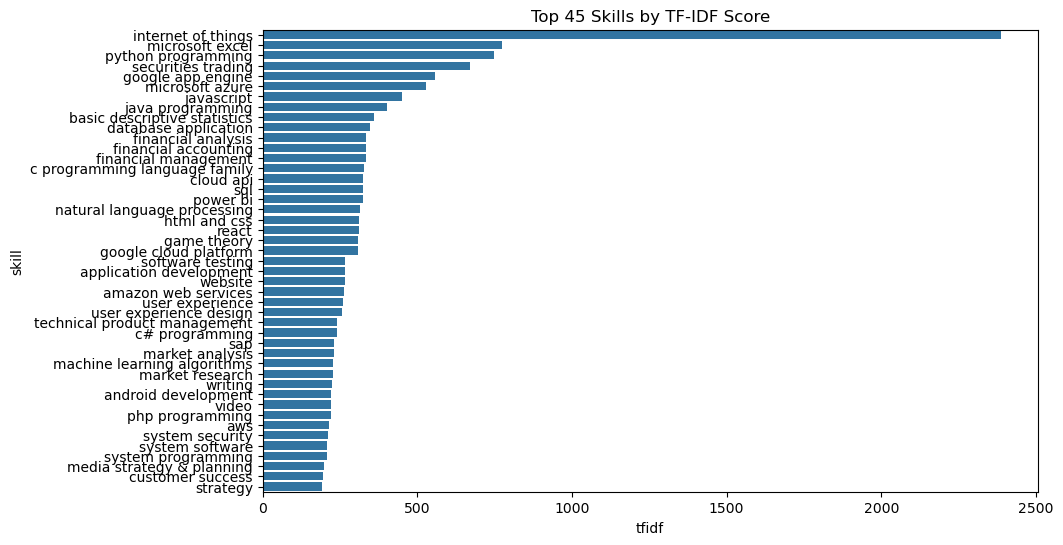

In [300]:
# Plot the top 45 TF-IDF skills
plt.figure(figsize=(10,6))
sns.barplot(data=top45_tfidf, x="tfidf", y="skill")
plt.title("Top 45 Skills by TF-IDF Score")
plt.show()

<h1>EMBEDDING CLUSTER REPRESENTATIVES</h1>

In [301]:
# Load a pre-trained sentence embedding model for skill text
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings for each unique skill (L2-normalized for clustering)
embeddings = model.encode(unique_skills, normalize_embeddings=True)

In [302]:
# Reduce high-dimensional embeddings to 2D for visual plotting
reducer = umap.UMAP(random_state=42)
emb2d = reducer.fit_transform(embeddings)

C:\Users\habee\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [303]:
# Choose number of clusters (e.g., 145 clusters for grouping skills)
k = 145
kmeans = KMeans(n_clusters=k, random_state=42).fit(embeddings)
labels = kmeans.labels_

C:\Users\habee\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [304]:
# Group skills into clusters based on KMeans labels
cluster_to_skills = {i: [] for i in range(k)}
for skill, label in zip(unique_skills, labels):
    cluster_to_skills[label].append(skill)

# Select one representative skill per cluster (the most frequent skill)
representatives = []
for c in cluster_to_skills:
    cluster_skills = cluster_to_skills[c]
    if not cluster_skills:
        continue
    
    # Choose representative based on highest frequency in dataset
    repskill = max(cluster_skills, key=lambda s: skill_counts[s])
    representatives.append(repskill)

In [305]:
# Take first 45 representative skills as a demo subset
rep_skills = representatives[:45]

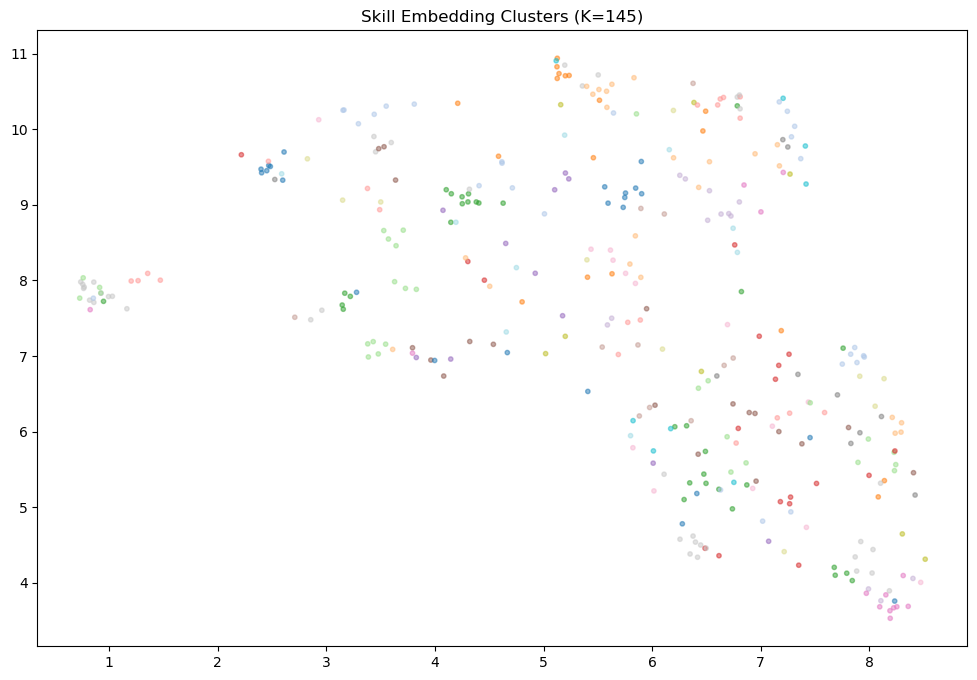

In [306]:
# Plot the 2D visualization of skill clusters
plt.figure(figsize=(12,8))
plt.scatter(emb2d[:,0], emb2d[:,1], c=labels, cmap="tab20", s=10, alpha=0.5)
plt.title("Skill Embedding Clusters (K=145)")
plt.show()

<h1>HYBRID METHOD — CLUSTERING + TF-IDF INSIDE CLUSTERS</h1>

In [307]:
# Step 1: Cluster skills into 30 groups using their embeddings
K_hybrid = 55
kmeans_h = KMeans(n_clusters=K_hybrid, random_state=42).fit(embeddings)
labels_h = kmeans_h.labels_

# Build dictionary: cluster_id -> list of skills in that cluster
cluster_to_skills_h = {i: [] for i in range(K_hybrid)}
for skill, label in zip(unique_skills, labels_h):
    cluster_to_skills_h[label].append(skill)

C:\Users\habee\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [308]:
# Build a dictionary for fast TF-IDF score lookup
tfidf_lookup = dict(zip(tfidf_df["skill"], tfidf_df["tfidf"]))

In [309]:
# Step 2: From each cluster, pick the skill with the highest TF-IDF score
hybrid_skills = []
for c in range(K_hybrid):
    cls = cluster_to_skills_h[c]
    if not cls:
        continue
    
    # Select the skill in this cluster with the strongest TF-IDF signal
    best = max(cls, key=lambda s: tfidf_lookup.get(s, 0))
    hybrid_skills.append(best)

In [310]:
# Take the first 45 clusters as the final hybrid-selected skills
hybrid_final45 = hybrid_skills[:45]
hybrid_final45

['javascript',
 'website',
 'technical product management',
 'financial accounting',
 'application development',
 'system security',
 'digital marketing',
 'microsoft excel',
 'regulations and compliance',
 'market analysis',
 'swift programming',
 'people management',
 'network architecture',
 'theoretical computer science',
 'bayesian network',
 'negotiation',
 'people analysis',
 'search engine optimization',
 'sap',
 'machine learning software',
 'user experience',
 'database application',
 'angular',
 'basic descriptive statistics',
 'jira',
 'spatial analysis',
 'interactive design',
 'strategy and operations',
 'big data',
 'python programming',
 'media strategy & planning',
 'financial analysis',
 'human learning',
 'google app engine',
 'writing',
 'android development',
 'software testing',
 'risk management',
 'game theory',
 'web development',
 'supply chain and logistics',
 'user experience design',
 'agile software development',
 'internet of things',
 'power bi']

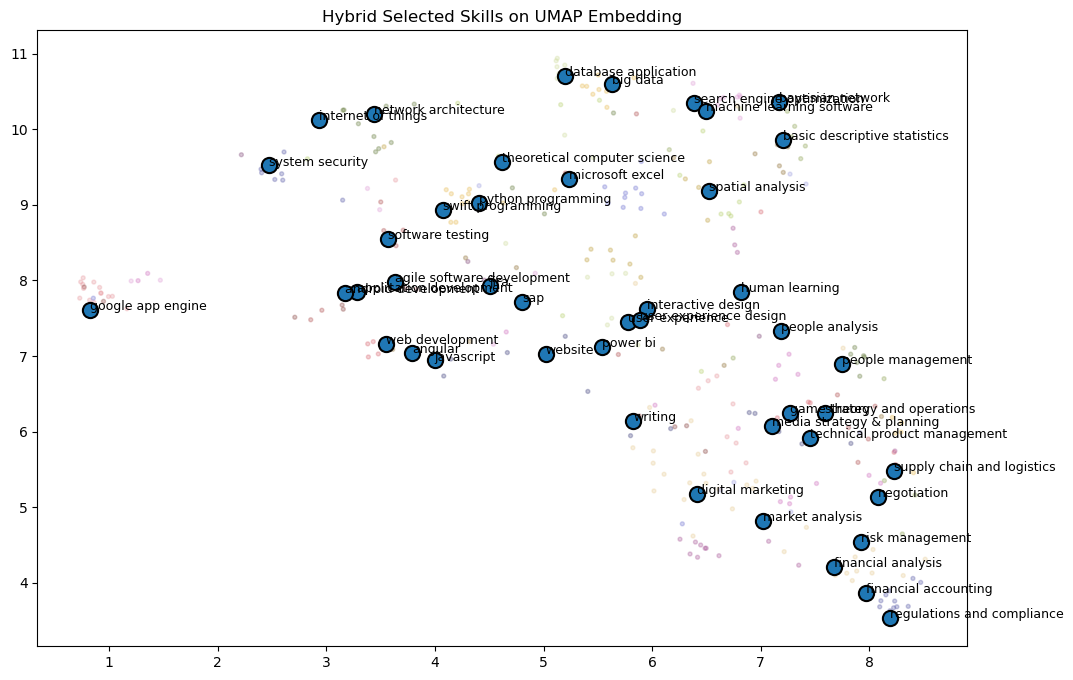

In [311]:
# Plot the embedding with clusters and highlight the selected hybrid skills
plt.figure(figsize=(12,8))
plt.scatter(emb2d[:,0], emb2d[:,1], c=labels_h, cmap="tab20b", s=8, alpha=0.3)

# Get embedding indices of selected skills
indices = [unique_skills.index(s) for s in hybrid_final45]

# Highlight the selected hybrid skills on the plot
plt.scatter(emb2d[indices,0], emb2d[indices,1], s=120, edgecolor="black", linewidth=1.5)

# Label each selected point with the skill name
for i, idx in enumerate(indices):
    plt.text(emb2d[idx,0], emb2d[idx,1], hybrid_final45[i], fontsize=9)

plt.title("Hybrid Selected Skills on UMAP Embedding")
plt.show()

<h1>Compare:</h1>

In [312]:
comparison = pd.DataFrame({
    "frequency": top45_freq,
    "tfidf": top45_tfidf["skill"].tolist(),
    "embedding_rep": rep_skills[:45],
    "hybrid": hybrid_final45
})

comparison

,frequency,tfidf,embedding_rep,hybrid
0,internet of things,internet of things,javascript,javascript
1,python programming,microsoft excel,wordpress,website
2,microsoft excel,python programming,technical product management,technical product management
3,google app engine,securities trading,general accounting,financial accounting
4,securities trading,google app engine,application development,application development
5,microsoft azure,microsoft azure,system security,system security
6,database application,javascript,digital marketing,digital marketing
7,financial analysis,java programming,interactive data visualization,microsoft excel
8,financial accounting,basic descriptive statistics,cloud standards,regulations and compliance
9,financial management,database application,market analysis,market analysis


In [313]:
def compute_coverage(selected_skills, df):
    selected = set(selected_skills)
    # check if course contains any selected skill
    has_skill = df["skills_list"].apply(lambda x: any(s in selected for s in x))
    return has_skill.sum() / len(df) * 100



In [314]:
coverage_freq = compute_coverage(top45_freq, df)
coverage_tfidf = compute_coverage(top45_tfidf["skill"].tolist(), df)
coverage_embed = compute_coverage(rep_skills[:45], df)
coverage_hybrid = compute_coverage(hybrid_final45, df)

print("Coverage Comparison:")
print(f"Top-45 Frequency:       {coverage_freq:.2f}%")
print(f"Top-45 TF-IDF:          {coverage_tfidf:.2f}%")
print(f"Top-45 Embedding:       {coverage_embed:.2f}%")
print(f"Hybrid Final-45:        {coverage_hybrid:.2f}%")


Coverage Comparison:
Top-45 Frequency:       71.75%
Top-45 TF-IDF:          77.58%
Top-45 Embedding:       43.65%
Hybrid Final-45:        69.29%


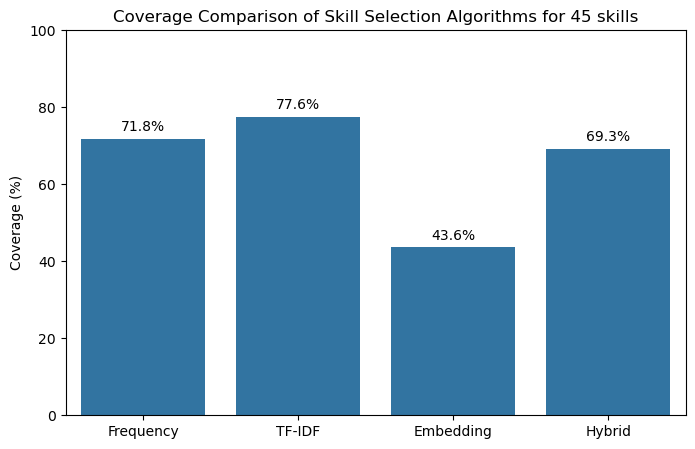

In [315]:
methods = ["Frequency", "TF-IDF", "Embedding", "Hybrid"]
coverages = [coverage_freq, coverage_tfidf, coverage_embed, coverage_hybrid]

skillVal=45
plt.figure(figsize=(8,5))
sns.barplot(x=methods, y=coverages)
plt.ylabel("Coverage (%)")
plt.title(f"Coverage Comparison of Skill Selection Algorithms for {skillVal} skills")
plt.ylim(0, 100)

# label bars with values
for i, v in enumerate(coverages):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center')

plt.savefig(f"coverage_comparison_for_{skillVal}_skills.png", dpi=300, bbox_inches="tight")

plt.show()


In [316]:
# Make a copy to avoid modifying df accidentally
df_hybrid = df.copy()

# Add a column for each selected skill
for skill in hybrid_final45:
    df_hybrid[skill] = df_hybrid["skills_list"].apply(
        lambda skills: 1 if skill in skills else 0
    )

df_hybrid.head()

,course_title,rating,review_count,skills_list,platform,level,duration,skills_text,javascript,website,...,android development,software testing,risk management,game theory,web development,supply chain and logistics,user experience design,agile software development,internet of things,power bi
0,Google Cybersecurity,4.8,16400.0,"[databases, network architecture, risk managem...",coursera,1,78.21,databases | network architecture | risk manage...,0,0,...,0,0,1,0,0,0,0,0,0,0
1,Google Data Analytics,4.8,133400.0,"[data visualization software, small data, big ...",coursera,1,78.21,data visualization software | small data | big...,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Google Project Management:,4.8,97300.0,"[risk management, influencing, change manageme...",coursera,1,78.21,risk management | influencing | change managem...,0,0,...,0,0,1,0,0,1,0,1,0,0
3,Google Digital Marketing & E-commerce,4.8,21400.0,"[social media, media strategy & planning, web ...",coursera,1,78.21,social media | media strategy & planning | web...,0,0,...,0,0,0,0,1,0,0,0,0,0
4,Google IT Support,4.8,181400.0,"[network security, network analysis, cloud com...",coursera,1,78.21,network security | network analysis | cloud co...,0,0,...,0,0,0,0,0,0,0,0,0,0


In [317]:
df_hybrid.to_csv("all-courses-hybrid-45-skills.csv", index=False)
print("Saved all-courses-hybrid-45-skills.csv")


Saved all-courses-hybrid-45-skills.csv


In [318]:
methods = {
    "frequency": top45_freq,
    "tfidf": top45_tfidf["skill"].tolist(),
    "embedding": rep_skills[:45],
}

for name, skills in methods.items():
    df_out = df.copy()
    
    for skill in skills:
        df_out[skill] = df_out["skills_list"].apply(lambda x: 1 if skill in x else 0)
    
    df_out.to_csv(f"all-courses-with-{name}-skills.csv", index=False)
    print(f"Saved all-courses-with-{name}-skills.csv")


Saved all-courses-with-frequency-skills.csv
Saved all-courses-with-tfidf-skills.csv
Saved all-courses-with-embedding-skills.csv
